In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("social_media_usage_1000.csv")
print("---Preview of 1st Five Records:---\n",df.head())
print("\n---Diplaying info about Columns and Data Types:---\n")
print(df.info())

---Preview of 1st Five Records:---
    User_ID   Age  Gender  Instagram_hrs  Facebook_hrs  YouTube_hrs  \
0        1  51.0    Male            0.8           2.1          1.2   
1        2  41.0  Female            2.6           2.2          3.5   
2        3   NaN    Male            3.5           1.3          3.6   
3        4  55.0  Female            3.2           1.4          0.6   
4        5  20.0  Female            NaN           0.3          4.4   

       Purpose  Location Device_Type  Daily_Sessions  
0    Education     Urban     Desktop               5  
1          NaN  Suburban     Desktop              11  
2  Socializing     Rural      Mobile               2  
3         Work     Rural      Mobile               1  
4  Socializing     Urban      Mobile               2  

---Diplaying info about Columns and Data Types:---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ----

In [107]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Age'].fillna(df['Age'].median(),inplace=True)
for col in ['Instagram_hrs', 'Facebook_hrs', 'YouTube_hrs']:
  df[col].fillna(df[col].mean(), inplace=True)
df['Purpose'].fillna('Unknown', inplace=True)

/tmp/ipython-input-2766800091.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [5]:
df['Total_Hours'] = df[['Instagram_hrs', 'Facebook_hrs', 'YouTube_hrs']].sum(axis=1)

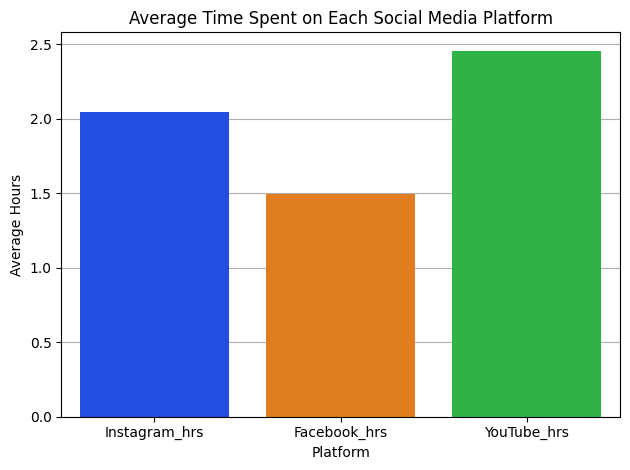

<Figure size 640x480 with 0 Axes>

In [65]:
from re import X
mean_platform = df[['Instagram_hrs','Facebook_hrs','YouTube_hrs']].mean()
fig, ax = plt.subplots()
sns.barplot(x=mean_platform.index, y=mean_platform.values, ax=ax, hue=mean_platform.index, palette='bright', legend=False)
plt.xlabel('Platform')
plt.ylabel('Average Hours')
plt.title('Average Time Spent on Each Social Media Platform')
plt.grid(True,axis='y')
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

/tmp/ipython-input-1038682466.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Gender'], y=df['Total_Hours'], palette='viridis')


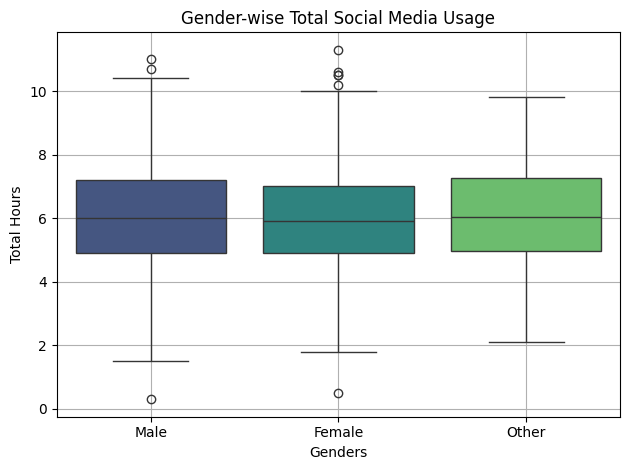

<Figure size 640x480 with 0 Axes>

In [52]:
sns.boxplot(x=df['Gender'], y=df['Total_Hours'], palette='viridis')
plt.xlabel('Genders')
plt.ylabel('Total Hours')
plt.title('Gender-wise Total Social Media Usage')
plt.tight_layout()
plt.grid()
plt.figure()
plt.show()

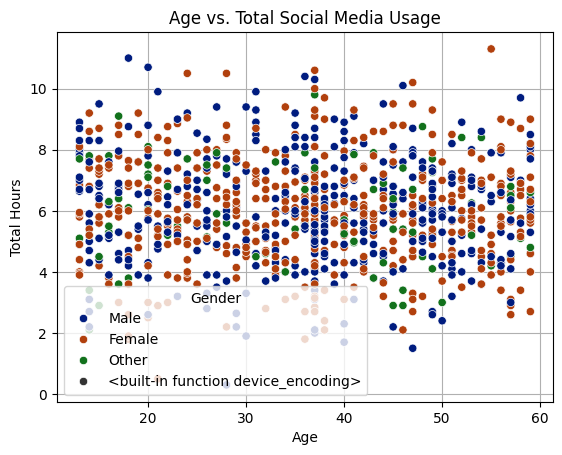

<Figure size 640x480 with 0 Axes>

In [81]:
fig, ax = plt.subplots()
sns.scatterplot(x=df['Age'], y=df['Total_Hours'], ax=ax, hue=df['Gender'], palette='dark', style =device_encoding)
plt.grid()
ax.set_axisbelow(True)
plt.xlabel('Age')
plt.ylabel('Total Hours')
plt.title('Age vs. Total Social Media Usage')
plt.figure()
plt.show()

/tmp/ipython-input-2660683566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=locat_usage, x='Location', y='Total_Hours', palette='bright', ax=ax)


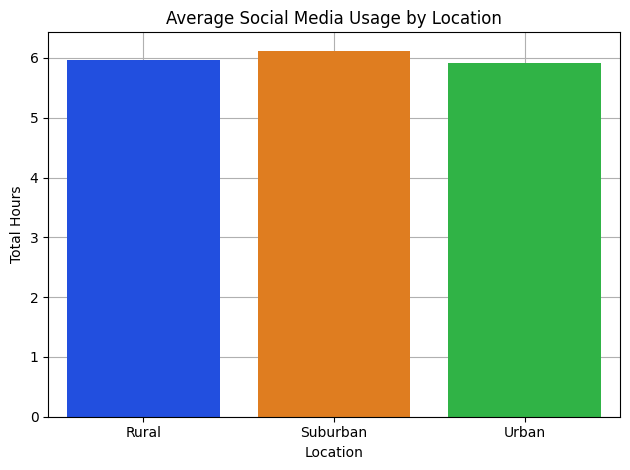

<Figure size 640x480 with 0 Axes>

In [74]:
locat_usage = df.groupby('Location')['Total_Hours'].mean().reset_index()
fig, ax = plt.subplots()
sns.barplot(data=locat_usage, x='Location', y='Total_Hours', palette='bright', ax=ax)
plt.title('Average Social Media Usage by Location')
plt.xlabel('Location')
plt.ylabel('Total Hours')
plt.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

/tmp/ipython-input-3368051199.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Purpose'], y=df['Total_Hours'], ax=ax, palette='dark')
/tmp/ipython-input-3368051199.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


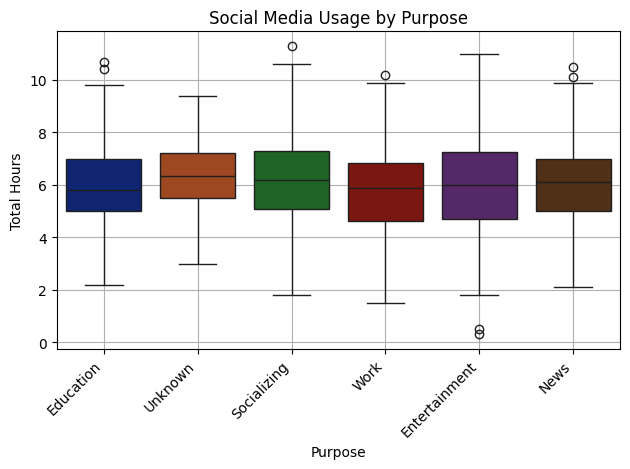

<Figure size 640x480 with 0 Axes>

In [78]:
fig,ax = plt.subplots()
sns.boxplot(x=df['Purpose'], y=df['Total_Hours'], ax=ax, palette='dark')
plt.xlabel('Purpose')
plt.ylabel('Total Hours')
plt.title('Social Media Usage by Purpose')
plt.grid()
ax.set_axisbelow(True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.figure()
plt.show()

/tmp/ipython-input-4104761996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Device_Type'], y=df['Daily_Sessions'], ax=ax, palette='bright')


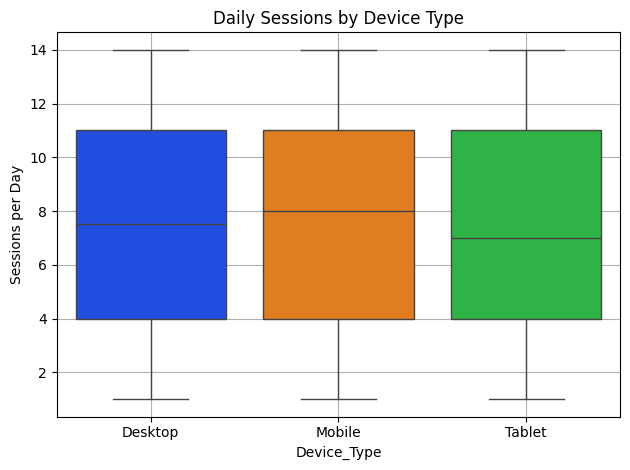

<Figure size 640x480 with 0 Axes>

In [79]:
fig,ax = plt.subplots()
sns.boxplot(x=df['Device_Type'], y=df['Daily_Sessions'], ax=ax, palette='bright')
plt.xlabel('Device_Type')
plt.ylabel('Sessions per Day')
plt.title('Daily Sessions by Device Type')
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

In [84]:
top_user = df.loc[df['Total_Hours'].idxmax()]
print(top_user)

User_ID                   865
Age                      55.0
Gender                 Female
Instagram_hrs             4.0
Facebook_hrs              3.3
YouTube_hrs               4.0
Purpose           Socializing
Location                Rural
Device_Type            Mobile
Daily_Sessions             13
Total_Hours              11.3
Name: 864, dtype: object


In [114]:
filter_users = df[df['Age'] <18]
young_minimalist = filter_users.loc[filter_users['Total_Hours'].idxmin()]
print(young_minimalist)

User_ID                   492
Age                      14.0
Gender                  Other
Instagram_hrs             1.0
Facebook_hrs             -0.0
YouTube_hrs               1.1
Purpose           Socializing
Location             Suburban
Device_Type            Tablet
Daily_Sessions              2
Total_Hours               2.1
Name: 491, dtype: object


In [120]:
print("\nName: Sanjay Kumaran D\nCollege: Vel Tech Multi Tech Dr.Rangarajan Dr.Sakunthala Engineering College\nProject Week2 Done\nEmail: sanjaykumaran6907@gmail.com")


Name: Sanjay Kumaran D
College: Vel Tech Multi Tech Dr.Rangarajan Dr.Sakunthala Engineering College
Project Week2 Done
Email: sanjaykumaran6907@gmail.com
